# Gaussian Elimination and Solution Sets

This notebook accompanies Lecture 01, **Systems of Linear Equations and Matrices**. It is a computational companion—not a second version of the lecture. Use the slides for the mathematical ideas and this notebook to carry out calculations, test predictions, and interpret results.

We use two complementary packages:

- **SymPy** for exact row operations, echelon forms, ranks, symbolic solution sets, and exact residuals.
- **NumPy** for floating-point solutions and numerical residual checks.

**Working habit:** pause at each prediction prompt before running the next code cell.

### Run the notebook locally or in Colab

Use Jupyter with the `qmcpy` environment, or open a private working copy in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/01-systems-and-matrices.ipynb)

Colab does not save changes back to the course repository; use **File → Save a copy in Drive** if you want to keep your work.

In [1]:
import sys

colab = "google.colab" in sys.modules
if colab:
    get_ipython().run_line_magic(
        "pip",
        "install -q git+https://github.com/fjhickernell/HickernellAcademicLib.git",
    )

In [2]:
import numpy as np
import sympy as sp
from IPython.display import Math, display
from sympy import Matrix

from classlib.nbviz import show_augmented, show_mat

sp.init_printing()

## 1. Follow elimination exactly with SymPy

### A. Forward elimination

Lecture 01 returns repeatedly to

$$
\begin{aligned}
x+2y-z&=2,\\
2x-y+z&=-3,\\
3x+y+2z&=1.
\end{aligned}
$$

The coefficient matrix $\mathsf{A}$ and right-hand side $\boldsymbol{b}$ store the system as $\mathsf{A}\boldsymbol{x}=\boldsymbol{b}$.

#### Change the equations and run again

To investigate another three-equation system in $x,y,z$, edit only `A` and `b` in the next cell. Then choose **Kernel → Restart Kernel and Run All Cells** in JupyterLab (or **Runtime → Restart session and run all** in Colab). Sections 1 and 2 will repeat elimination, back substitution when it applies, the exact SymPy solution, and the NumPy comparison for your new system. The later three-outcome and circuit sections remain fixed reference examples.

In [3]:
# EDITABLE INPUT: change these entries, then restart the kernel and run all cells.
x, y, z = sp.symbols("x y z")
variables = (x, y, z)

A = Matrix([
    [1,  2, -1],
    [2, -1,  1],
    [3,  1,  2],
])
b = Matrix([2, -3, 1])

show_augmented(A, b)

<IPython.core.display.Math object>

#### Predict first

Before running the next cell, predict the matrices produced by

1. $R_2\leftarrow R_2-2R_1$,
2. $R_3\leftarrow R_3-3R_1$, and then
3. $R_3\leftarrow R_3-R_2$.

Each operation is reversible, so every displayed system must have the same solution set.

In [4]:
def forward_elimination(A, b):
    """Return an echelon augmented matrix and every reversible row step."""
    matrix = A.row_join(b)
    steps = [("Start", matrix.copy())]
    pivot_row = 0

    for pivot_col in range(A.cols):
        candidates = [
            row for row in range(pivot_row, matrix.rows)
            if matrix[row, pivot_col] != 0
        ]
        if not candidates:
            continue

        swap_row = candidates[0]
        if swap_row != pivot_row:
            matrix.row_swap(pivot_row, swap_row)
            steps.append((
                f"R{pivot_row + 1} ↔ R{swap_row + 1}",
                matrix.copy(),
            ))

        pivot = matrix[pivot_row, pivot_col]
        for row in range(pivot_row + 1, matrix.rows):
            if matrix[row, pivot_col] == 0:
                continue
            factor = sp.simplify(matrix[row, pivot_col] / pivot)
            matrix.row_op(
                row,
                lambda entry, j: sp.simplify(
                    entry - factor * matrix[pivot_row, j]
                ),
            )
            steps.append((
                f"R{row + 1} ← R{row + 1} - ({factor})R{pivot_row + 1}",
                matrix.copy(),
            ))

        pivot_row += 1
        if pivot_row == matrix.rows:
            break

    return matrix, steps


echelon_augmented, elimination_steps = forward_elimination(A, b)
for label, matrix in elimination_steps:
    print(label)
    show_augmented(matrix[:, :-1], matrix[:, -1])

Start


<IPython.core.display.Math object>

R2 ← R2 - (2)R1


<IPython.core.display.Math object>

R3 ← R3 - (3)R1


<IPython.core.display.Math object>

R3 ← R3 - (1)R2


<IPython.core.display.Math object>

### B. Back substitution

Forward elimination produces an equivalent row echelon system. When a square system has a pivot in every variable column, back substitution starts with the last equation and works upward:

1. solve the last equation for $z$;
2. substitute that value into the second equation and solve for $y$;
3. substitute both known values into the first equation and solve for $x$.

The next cell performs and displays those substitutions. If the edited system is inconsistent or has a free variable, it reports that ordinary back substitution does not produce one unique vector.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

solution from back substitution:


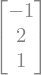

exact residual A*x - b:


SymPy solution set:


In [5]:
def back_substitution(echelon):
    """Solve a square full-rank echelon system from bottom to top."""
    coefficient_part = echelon[:, :-1]
    n = coefficient_part.cols
    if coefficient_part.rows != n or coefficient_part.rank() < n:
        return None, []

    solution = sp.zeros(n, 1)
    steps = []
    for row in range(n - 1, -1, -1):
        pivot = coefficient_part[row, row]
        if pivot == 0:
            return None, []
        known_sum = sp.simplify(sum(
            coefficient_part[row, col] * solution[col]
            for col in range(row + 1, n)
        ))
        adjusted_rhs = sp.simplify(echelon[row, -1] - known_sum)
        solution[row] = sp.simplify(adjusted_rhs / pivot)
        steps.append((
            row, echelon[row, -1], known_sum, pivot, solution[row]
        ))

    return solution, steps


solution_exact, substitution_steps = back_substitution(echelon_augmented)
if solution_exact is None:
    print("Back substitution does not yield one unique solution for this system.")
else:
    for row, right_side, known_sum, pivot, value in substitution_steps:
        display(Math(
            rf"{sp.latex(variables[row])}"
            rf"=\frac{{{sp.latex(right_side)}-({sp.latex(known_sum)})}}"
            rf"{{{sp.latex(pivot)}}}={sp.latex(value)}"
        ))
    print("solution from back substitution:")
    show_mat(solution_exact)
    print("exact residual A*x - b:")
    show_mat(A * solution_exact - b)

print("SymPy solution set:")
display(sp.linsolve((A, b), variables))

## 2. Solve the same system numerically with NumPy

NumPy's `np.linalg.solve` is designed for floating-point computation. Use it for a square system that has a unique solution, then check the result against the original equations with a residual.

In [6]:
A_np = np.array(A, dtype=float)
b_np = np.array(b, dtype=float).ravel()
rank_np = np.linalg.matrix_rank(A_np)

if A_np.shape[0] != A_np.shape[1] or rank_np < A_np.shape[1]:
    print("NumPy square solve skipped: the coefficient matrix is not square and full rank.")
else:
    solution_np = np.linalg.solve(A_np, b_np)
    residual_np = A_np @ solution_np - b_np
    print("NumPy solution:     ", solution_np)
    print("NumPy residual:     ", residual_np)
    print("residual 2-norm:   ", np.linalg.norm(residual_np))
    if solution_exact is not None:
        exact_as_float = np.array(solution_exact, dtype=float).ravel()
        print("difference from exact solution:", solution_np - exact_as_float)

NumPy solution:      [-1.  2.  1.]
NumPy residual:      [ 8.8817842e-16 -8.8817842e-16  0.0000000e+00]
residual 2-norm:    1.2560739669470201e-15
difference from exact solution: [-2.22044605e-16  4.44089210e-16  2.22044605e-16]


The exact and numerical answers agree here. They are not the same kind of object: SymPy preserves exact integers and fractions, while NumPy stores floating-point approximations. Converting a NumPy result to a SymPy matrix can improve its display, but it does not recover exact arithmetic that was already rounded.

## 3. Compare the three possible outcomes

Keep the first two equations fixed and vary only the third:

| System | Third equation | Predict |
|---|---|---|
| unique | $3x+y+2z=1$ | zero, one, or infinitely many solutions? |
| inconsistent | $3x+y=1$ | zero, one, or infinitely many solutions? |
| dependent | $3x+y=-1$ | zero, one, or infinitely many solutions? |

Make all three predictions before using the exact classifier below.

In [7]:
def classify_system(A, b):
    """Classify A*x=b from the exact ranks of A and [A|b]."""
    augmented = A.row_join(b)
    rank_A = A.rank()
    rank_augmented = augmented.rank()

    if rank_A < rank_augmented:
        outcome = "no solutions"
    elif rank_A == A.cols:
        outcome = "exactly one solution"
    else:
        outcome = "infinitely many solutions"

    return outcome, rank_A, rank_augmented


def report_system(name, A, b, variables):
    outcome, rank_A, rank_augmented = classify_system(A, b)
    echelon = A.row_join(b).echelon_form()

    print(f"{name}: {outcome}")
    print(f"rank(A) = {rank_A}, rank([A|b]) = {rank_augmented}")
    print("echelon form:")
    show_augmented(echelon[:, :-1], echelon[:, -1])
    print("solution set:")
    display(sp.linsolve((A, b), variables))

Unique system: exactly one solution
rank(A) = 3, rank([A|b]) = 3
echelon form:


<IPython.core.display.Math object>

solution set:


------------------------------------------------------------
Inconsistent system: no solutions
rank(A) = 2, rank([A|b]) = 3
echelon form:


<IPython.core.display.Math object>

solution set:


------------------------------------------------------------
Dependent system: infinitely many solutions
rank(A) = 2, rank([A|b]) = 2
echelon form:


<IPython.core.display.Math object>

solution set:


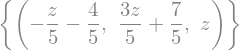

------------------------------------------------------------


In [8]:
A_unique = Matrix([
    [1,  2, -1],
    [2, -1,  1],
    [3,  1,  2],
])
b_unique = Matrix([2, -3, 1])

A_inconsistent = Matrix([
    [1,  2, -1],
    [2, -1,  1],
    [3,  1,  0],
])
b_inconsistent = Matrix([2, -3, 1])

A_dependent = A_inconsistent
b_dependent = Matrix([2, -3, -1])

systems = [
    ("Unique system", A_unique, b_unique),
    ("Inconsistent system", A_inconsistent, b_inconsistent),
    ("Dependent system", A_dependent, b_dependent),
]

for name, A_case, b_case in systems:
    report_system(name, A_case, b_case, variables)
    print("-" * 60)

Interpret the evidence before focusing on the labels:

- A row $[\,0\;0\;0\mid c\,]$ with $c\ne0$ is a contradiction, so the system is inconsistent.
- A consistent system with a pivot in every variable column has exactly one solution.
- A consistent system with fewer pivots than variables has at least one free variable and infinitely many solutions.

The exact rank test encodes these same facts. It does not replace reading the echelon form.

### What NumPy can—and cannot—tell us here

Both the inconsistent and dependent coefficient matrices are singular. A numerical rank check therefore warns us not to call `np.linalg.solve`, which is intended for a square matrix of full rank. Rank deficiency alone does **not** distinguish no solutions from infinitely many. The exact augmented-matrix evidence above makes that distinction. Numerical rank also depends on a floating-point tolerance, so SymPy's exact ranks are authoritative for these exact examples.

In [9]:
def numpy_square_report(name, A, b):
    A_float = np.array(A, dtype=float)
    b_float = np.array(b, dtype=float).ravel()
    rank = np.linalg.matrix_rank(A_float)
    print(f"{name}: numerical rank {rank} of {A_float.shape[1]} columns")
    if rank < A_float.shape[1]:
        print("  skip np.linalg.solve: coefficient matrix is rank deficient")
        return
    answer = np.linalg.solve(A_float, b_float)
    residual_norm = np.linalg.norm(A_float @ answer - b_float)
    print(f"  solution {answer}")
    print(f"  residual 2-norm {residual_norm:.3e}")


numpy_square_report("Unique system", A_unique, b_unique)
numpy_square_report("Inconsistent system", A_inconsistent, b_inconsistent)
numpy_square_report("Dependent system", A_dependent, b_dependent)

Unique system: numerical rank 3 of 3 columns
  solution [-1.  2.  1.]
  residual 2-norm 1.256e-15
Inconsistent system: numerical rank 2 of 3 columns
  skip np.linalg.solve: coefficient matrix is rank deficient
Dependent system: numerical rank 2 of 3 columns
  skip np.linalg.solve: coefficient matrix is rank deficient


### Verify the parameterized solution

For the dependent system, $z$ is the free variable. Lecture 01 gives

$$
(x,y,z)=\left(\frac{-4-z}{5},\frac{7+3z}{5},z\right).
$$

The symbolic residual should be zero for every real value of $z$.

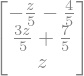

symbolic residual:


In [10]:
parameterized_solution = Matrix([
    (-4 - z) / 5,
    (7 + 3 * z) / 5,
    z,
])

show_mat(parameterized_solution)
print("symbolic residual:")
show_mat(sp.simplify(A_dependent * parameterized_solution - b_dependent))

## 4. A resistance network

The Lecture 01 network uses clockwise mesh currents $I_1,I_2,I_3$ in milliamperes and resistances in kilohms:

$$
\begin{aligned}
4I_1-3I_2&=9,\\
-3I_1+7I_2-2I_3&=0,\\
-2I_2+4I_3&=0.
\end{aligned}
$$

### Predict first

Do you expect zero, one, or infinitely many current vectors? Estimate which current should be largest before solving.

In [11]:
I1, I2, I3 = sp.symbols("I_1 I_2 I_3")
current_variables = (I1, I2, I3)

A_circuit = Matrix([
    [ 4, -3,  0],
    [-3,  7, -2],
    [ 0, -2,  4],
])
b_circuit = Matrix([9, 0, 0])

show_augmented(A_circuit, b_circuit)
print("classification:", classify_system(A_circuit, b_circuit)[0])

<IPython.core.display.Math object>

classification: exactly one solution


echelon form:


<IPython.core.display.Math object>

exact SymPy currents in mA:


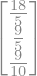

floating-point NumPy currents in mA:
[3.6 1.8 0.9]


In [12]:
circuit_echelon = A_circuit.row_join(b_circuit).echelon_form()
current_exact = A_circuit.LUsolve(b_circuit)

A_circuit_np = np.array(A_circuit, dtype=float)
b_circuit_np = np.array(b_circuit, dtype=float).ravel()
current_np = np.linalg.solve(A_circuit_np, b_circuit_np)

print("echelon form:")
show_augmented(circuit_echelon[:, :-1], circuit_echelon[:, -1])
print("exact SymPy currents in mA:")
show_mat(current_exact)
print("floating-point NumPy currents in mA:")
print(current_np)

The result is $(I_1,I_2,I_3)=(3.6,1.8,0.9)\,\mathrm{mA}$. Check both computations against the original loop equations.

In [13]:
residual_circuit_exact = A_circuit * current_exact - b_circuit
residual_circuit_np = A_circuit_np @ current_np - b_circuit_np

print("exact residual:")
show_mat(residual_circuit_exact)
print("numerical residual:", residual_circuit_np)
print("numerical residual 2-norm:", np.linalg.norm(residual_circuit_np))

exact residual:


numerical residual: [ 0.0000000e+00 -8.8817842e-16 -4.4408921e-16]
numerical residual 2-norm: 9.930136612989092e-16


### Replace two resistances by ideal wires

In the short-circuit model, the first top resistance and the left vertical resistance are both zero. The first loop equation becomes $0=9$.

Before running the next cell, predict the exact rank comparison, the decisive echelon row, and what the NumPy rank check will recommend.

In [14]:
A_short = Matrix([
    [0,  0,  0],
    [0,  4, -2],
    [0, -2,  4],
])
b_short = Matrix([9, 0, 0])

report_system("Short-circuit model", A_short, b_short, current_variables)
numpy_square_report("Short-circuit model", A_short, b_short)

Short-circuit model: no solutions
rank(A) = 2, rank([A|b]) = 3
echelon form:


<IPython.core.display.Math object>

solution set:


Short-circuit model: numerical rank 2 of 3 columns
  skip np.linalg.solve: coefficient matrix is rank deficient


Here $\operatorname{rank}(\mathsf{A})<\operatorname{rank}([\mathsf{A}\mid\boldsymbol{b}])$. The augmented column contributes the impossible constraint $0=9$, so no current vector can satisfy the idealized model. NumPy's rank check tells us to skip the square solver; the exact augmented system supplies the interpretation.

The contradiction is physical as well as algebraic: an ideal voltage source cannot drive a loop containing only ideal wire under this simplified resistance model.

## 5. Experiments

Try these after the main notebook runs successfully:

1. Change the source from $9\,\mathrm{V}$ to $12\,\mathrm{V}$. Predict how all three currents change before computing.
2. Change one resistance in `A_circuit`. Which current changes most? Verify the new solution with both exact and numerical residuals.
3. Change the dependent system's third right-hand side from $-1$ to $-1+\varepsilon$. For which values of $\varepsilon$ is the system consistent?
4. Construct your own $3\times3$ augmented matrix whose echelon form contains $[\,0\;0\;0\mid5\,]$.

exact currents for a 12 V source, in mA:


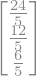

exact residual:


In [15]:
source_voltage = 12
b_experiment = Matrix([source_voltage, 0, 0])
current_experiment = A_circuit.LUsolve(b_experiment)

print(f"exact currents for a {source_voltage} V source, in mA:")
show_mat(current_experiment)
print("exact residual:")
show_mat(A_circuit * current_experiment - b_experiment)

## 6. What to retain

- Row operations expose information while preserving the solution set.
- Echelon form distinguishes a contradiction, a unique solution, and free variables.
- SymPy preserves exact structure; NumPy provides the floating-point numerical counterpart.
- A failed numerical square solve does not distinguish no solutions from infinitely many.
- Every computed solution should be interpreted and checked against the original system.
- In an applied model, translate an algebraic contradiction back into the physical setting.

Use computation to carry out row operations and test reasoning—not to replace the reasoning.